<a href="https://colab.research.google.com/github/PRManasa/part-2-cnn-computer-vision/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Task 1: Problem Identification

This is an image classification problem because each product image is classified into one category.

Classes: ['dent', 'normal', 'scratch', 'stain']
Number of classes: 4
Images per class:
{'dent': 120, 'normal': 120, 'scratch': 120, 'stain': 120}


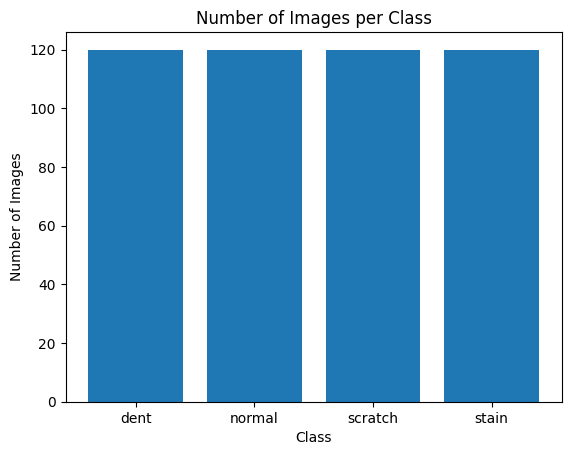

In [2]:
# Task 2: Dataset Exploration
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

image_dir = Path("/content/drive/MyDrive/ai_project_synthetic_datasets/part_2_cnn_computer_vision/images")

classes = sorted([folder.name for folder in image_dir.iterdir() if folder.is_dir()])
print("Classes:", classes)
print("Number of classes:", len(classes))

class_counts = {}

for class_name in classes:
    files = list((image_dir / class_name).glob("*"))
    class_counts[class_name] = len(files)

print("Images per class:")
print(class_counts)

plt.bar(class_counts.keys(), class_counts.values())
plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

dent image size: (96, 96)
normal image size: (96, 96)
scratch image size: (96, 96)
stain image size: (96, 96)


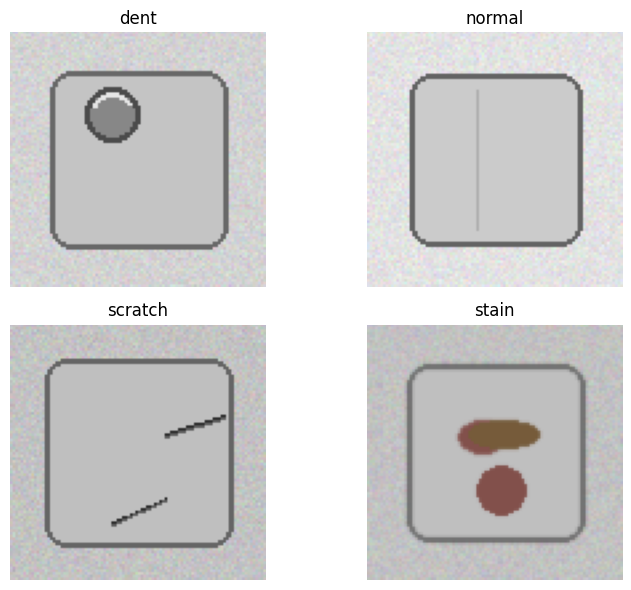

In [3]:
plt.figure(figsize=(8, 6))

for i, class_name in enumerate(classes):
    sample_image_path = list((image_dir / class_name).glob("*"))[0]
    img = Image.open(sample_image_path)

    print(class_name, "image size:", img.size)

    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
# Task 3: Image Preprocessing
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

img_size = (96, 96)
batch_size = 32
seed = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    image_dir,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    image_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Class names:", class_names)

Found 480 files belonging to 4 classes.
Using 384 files for training.
Found 480 files belonging to 4 classes.
Using 96 files for validation.
Class names: ['dent', 'normal', 'scratch', 'stain']


In [5]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

print("Image preprocessing completed.")

Image preprocessing completed.


In [6]:
# Task 4: CNN Model Creation
model = keras.Sequential([
    layers.Input(shape=(96, 96, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(len(class_names), activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       819,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 912,772 (3.48 MB)

 Trainable params: 912,772 (3.48 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Task 5: Model Training and Evaluation
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 89s 7s/step - accuracy: 0.2161 - loss: 1.4418 - val_accuracy: 0.2604 - val_loss: 1.3843
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 808ms/step - accuracy: 0.2917 - loss: 1.3809 - val_accuracy: 0.2188 - val_loss: 1.3879
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 597ms/step - accuracy: 0.3438 - loss: 1.3452 - val_accuracy: 0.5312 - val_loss: 1.3364
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 763ms/step - accuracy: 0.5078 - loss: 1.1889 - val_accuracy: 0.5000 - val_loss: 1.1018
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 878ms/step - accuracy: 0.5938 - loss: 0.8909 - val_accuracy: 0.6562 - val_loss: 0.8534
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 582ms/step - accuracy: 0.7031 - loss: 0.6959 - val_accuracy: 0.7083 - val_loss: 0.7361
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 719ms/step - accuracy: 0.7734 - loss: 0.5682 - val_accuracy: 0.7917 - val_loss: 0.5589
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 813ms/step - accuracy: 0.8490 - loss: 0.4037 - val_accuracy:

In [8]:
test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

print("Testing Loss:", test_loss)
print("Testing Accuracy:", test_accuracy)

Testing Loss: 0.35896220803260803
Testing Accuracy: 0.8333333134651184


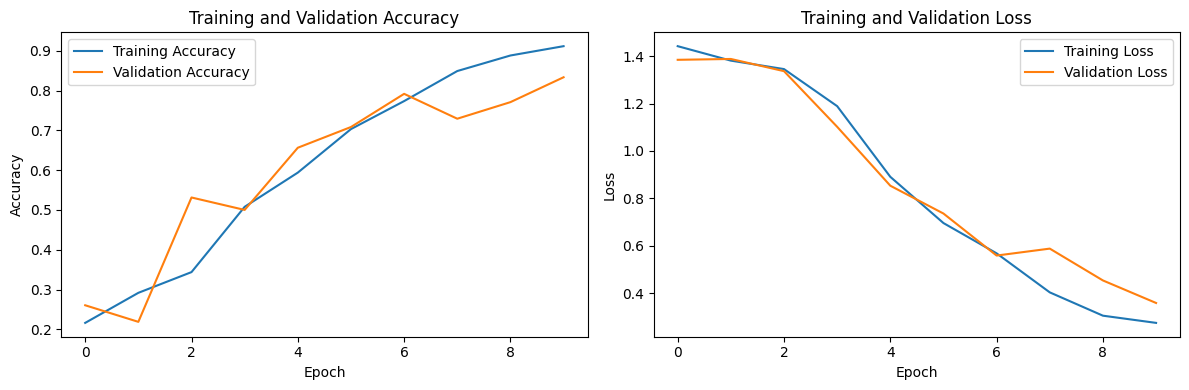

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("results/accuracy_loss_curves.png", bbox_inches="tight")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
Confusion Matrix:
[[19  0  2  1]
 [ 0 23  0  0]
 [ 6  4 20  0]
 [ 2  0  1 18]]
Classification Report:
              precision    recall  f1-score   support

        dent       0.70      0.86      0.78        22
      normal       0.85      1.00      0.92        23
     scratch       0.87      0.67      0.75        30
       stain       0.95      0.86      0.90        21

    accuracy                           0.83        96
   macro avg       0.84      0.85      0.84        96
weighted avg       0.84      0.83      0.83        96



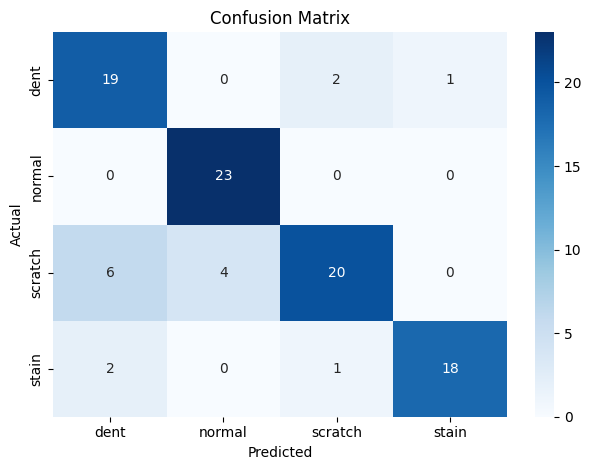

In [15]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("results/confusion_matrix.png", bbox_inches="tight")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step


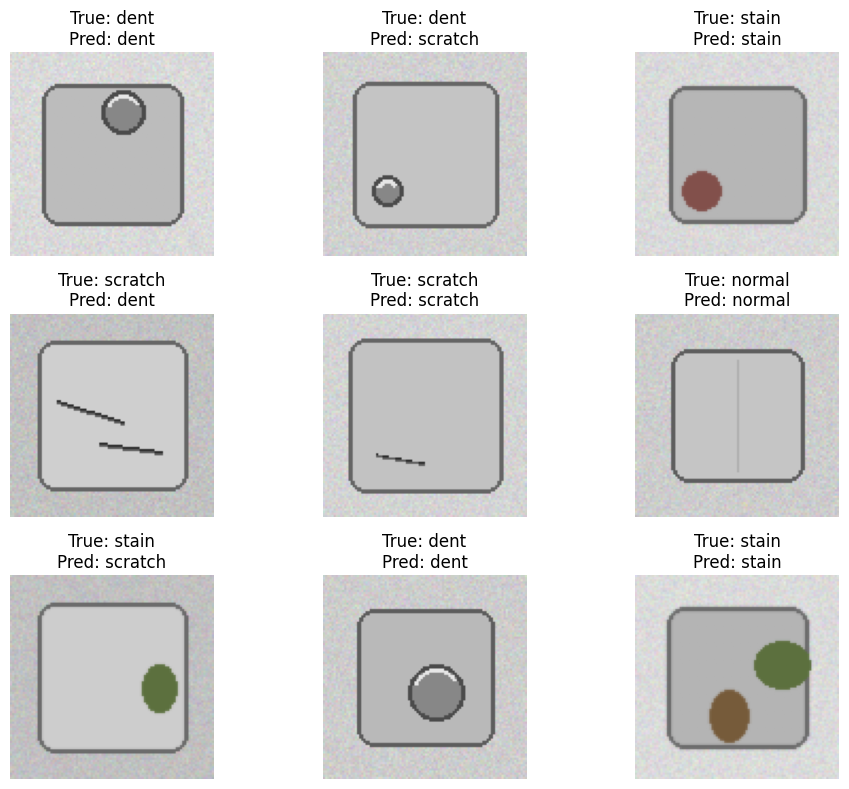

In [16]:
plt.figure(figsize=(10, 8))

for images, labels in test_ds.take(1):
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[predicted_labels[i]]}")
        plt.axis("off")

plt.tight_layout()
plt.savefig("sample_predictions/prediction_outputs.png", bbox_inches="tight")
plt.show()